# LightGBM

**Dataset:** `/kaggle/input/datasets/jasonkmrkn/fp-ml-clustering-artifacs`  
**Primary Metric:** F1-Score (karena class imbalance ~18% default)

---

### Ringkasan Skenario:
| Skenario | Deskripsi |
|----------|-----------|
| **1a** | Baseline , tanpa cluster features, default params |
| **1b** | Enhanced , dengan cluster features (+9 kolom), default params |
| **2a** | Enhanced + Default params |
| **2b** | Enhanced + Optuna Tuned params (50 trials) |

## Install & Import

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import time

from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
DATA_DIR = '/kaggle/input/datasets/jasonkmrkn/fp-ml-clustering-artifacs'

print('Import selesai')
print(f'LightGBM version: {lgb.__version__}')
print(f'Optuna version:   {optuna.__version__}')

Import selesai
LightGBM version: 4.6.0
Optuna version:   4.8.0


## Step 1 , Load Data

In [3]:
import os

def load_parquet(filename):
    return pd.read_parquet(os.path.join(DATA_DIR, filename))

# ── Encoded features
X_train = load_parquet('X_train_encoded.parquet')
X_val   = load_parquet('X_val_encoded.parquet')
X_test  = load_parquet('X_test_encoded.parquet')

# ── Labels
y_train = load_parquet('y_train.parquet')['Default']
y_val   = load_parquet('y_val.parquet')['Default']
y_test  = load_parquet('y_test.parquet')['Default']

# ── Cluster features
clust_train = load_parquet('cluster_features_train.parquet')
clust_val   = load_parquet('cluster_features_val.parquet')
clust_test  = load_parquet('cluster_features_test.parquet')

print('Data berhasil dimuat!')
print(f'   X_train shape      : {X_train.shape}')
print(f'   X_val shape        : {X_val.shape}')
print(f'   X_test shape       : {X_test.shape}')
print(f'   clust_train shape  : {clust_train.shape}')
print(f'   Default rate train : {y_train.mean():.2%}')
print(f'   Default rate val   : {y_val.mean():.2%}')
print(f'   Default rate test  : {y_test.mean():.2%}')

Data berhasil dimuat!
   X_train shape      : (174993, 46)
   X_val shape        : (37507, 46)
   X_test shape       : (37500, 46)
   clust_train shape  : (174993, 9)
   Default rate train : 17.56%
   Default rate val   : 17.56%
   Default rate test  : 17.56%


## Step 2 , Build Enhanced Datasets (concat cluster features)

In [4]:
# ── Enhanced = encoded features + cluster features (9 kolom tambahan)
# WAJIB reset_index(drop=True) sebelum concat karena index beda
X_train_enh = pd.concat(
    [X_train.reset_index(drop=True), clust_train.reset_index(drop=True)], axis=1
)
X_val_enh = pd.concat(
    [X_val.reset_index(drop=True), clust_val.reset_index(drop=True)], axis=1
)
X_test_enh = pd.concat(
    [X_test.reset_index(drop=True), clust_test.reset_index(drop=True)], axis=1
)

print('Enhanced dataset berhasil dibuat!')
print(f'   Baseline features  : {X_train.shape[1]} kolom')
print(f'   Enhanced features  : {X_train_enh.shape[1]} kolom (+{X_train_enh.shape[1] - X_train.shape[1]} cluster)')
print(f'   Cluster columns    : {list(clust_train.columns)}')

Enhanced dataset berhasil dibuat!
   Baseline features  : 46 kolom
   Enhanced features  : 55 kolom (+9 cluster)
   Cluster columns    : ['cluster_id', 'cluster_dist_0', 'cluster_dist_1', 'cluster_dist_2', 'cluster_dist_3', 'cluster_dist_4', 'cluster_dist_5', 'cluster_dist_6', 'cluster_dist_7']


## Helper Functions

In [5]:
def evaluate_model(model, X, y, label='', threshold=0.5):
    """Evaluasi model dan kembalikan dict hasil metrik."""
    y_proba = model.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    f1      = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_proba)
    pr_auc  = average_precision_score(y, y_proba)

    print(f'\n{"="*55}')
    print(f'  {label}')
    print(f'{"="*55}')
    print(f'  Threshold   : {threshold:.3f}')
    print(f'  F1-Score    : {f1:.4f}')
    print(f'  ROC-AUC     : {roc_auc:.4f}')
    print(f'  PR-AUC      : {pr_auc:.4f}')
    print(f'\n{classification_report(y, y_pred, target_names=["No Default", "Default"])}')

    return {
        'label'    : label,
        'threshold': threshold,
        'f1'       : f1,
        'roc_auc'  : roc_auc,
        'pr_auc'   : pr_auc,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
    }


def get_scale_pos_weight(y):
    """Hitung scale_pos_weight untuk handle class imbalance."""
    return (y == 0).sum() / (y == 1).sum()


def find_best_threshold(y_true, y_proba, n_steps=181):
    """Cari threshold yang memaksimalkan F1 di suatu set (biasanya Val)."""
    thresholds = np.linspace(0.05, 0.95, n_steps)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx]


print('Helper functions siap')
print(f'   scale_pos_weight : {get_scale_pos_weight(y_train):.4f}')

Helper functions siap
   scale_pos_weight : 4.6951


---
# SKENARIO 1: Ablation Cluster Features
## Baseline (1a) vs Enhanced (1b) , Default Params

### Skenario 1a , Baseline (tanpa cluster features)

In [6]:
print('Training Skenario 1a: Baseline ...')
t0 = time.time()

lgb_1a = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=get_scale_pos_weight(y_train),
    random_state=RANDOM_SEED,
    deterministic=True,
    force_row_wise=True,
    verbose=-1
)
lgb_1a.fit(X_train, y_train)

print(f'   Selesai dalam {time.time() - t0:.1f} detik')

Training Skenario 1a: Baseline ...
   Selesai dalam 1.8 detik


In [7]:
res_1a_val  = evaluate_model(lgb_1a, X_val,  y_val,  label='1a, Baseline  | Val Set')
res_1a_test = evaluate_model(lgb_1a, X_test, y_test, label='1a, Baseline  | Test Set')


  1a, Baseline  | Val Set
  Threshold   : 0.500
  F1-Score    : 0.8318
  ROC-AUC     : 0.9754
  PR-AUC      : 0.8919

              precision    recall  f1-score   support

  No Default       0.98      0.94      0.96     30921
     Default       0.77      0.90      0.83      6586

    accuracy                           0.94     37507
   macro avg       0.88      0.92      0.90     37507
weighted avg       0.94      0.94      0.94     37507


  1a, Baseline  | Test Set
  Threshold   : 0.500
  F1-Score    : 0.8362
  ROC-AUC     : 0.9764
  PR-AUC      : 0.8980

              precision    recall  f1-score   support

  No Default       0.98      0.94      0.96     30915
     Default       0.78      0.91      0.84      6585

    accuracy                           0.94     37500
   macro avg       0.88      0.93      0.90     37500
weighted avg       0.94      0.94      0.94     37500



### Skenario 1b , Enhanced (dengan cluster features)

In [8]:
print('Training Skenario 1b: Enhanced ...')
t0 = time.time()

lgb_1b = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=get_scale_pos_weight(y_train),
    random_state=RANDOM_SEED,
    deterministic=True,
    force_row_wise=True,
    verbose=-1
)
lgb_1b.fit(X_train_enh, y_train)

print(f'   Selesai dalam {time.time() - t0:.1f} detik')

Training Skenario 1b: Enhanced ...
   Selesai dalam 2.3 detik


In [9]:
res_1b_val  = evaluate_model(lgb_1b, X_val_enh,  y_val,  label='1b, Enhanced  | Val Set')
res_1b_test = evaluate_model(lgb_1b, X_test_enh, y_test, label='1b, Enhanced  | Test Set')


  1b, Enhanced  | Val Set
  Threshold   : 0.500
  F1-Score    : 0.8330
  ROC-AUC     : 0.9760
  PR-AUC      : 0.8937

              precision    recall  f1-score   support

  No Default       0.98      0.94      0.96     30921
     Default       0.77      0.91      0.83      6586

    accuracy                           0.94     37507
   macro avg       0.88      0.92      0.90     37507
weighted avg       0.94      0.94      0.94     37507


  1b, Enhanced  | Test Set
  Threshold   : 0.500
  F1-Score    : 0.8370
  ROC-AUC     : 0.9773
  PR-AUC      : 0.9019

              precision    recall  f1-score   support

  No Default       0.98      0.94      0.96     30915
     Default       0.77      0.91      0.84      6585

    accuracy                           0.94     37500
   macro avg       0.88      0.93      0.90     37500
weighted avg       0.94      0.94      0.94     37500



### Ringkasan Skenario 1: Baseline vs Enhanced

In [10]:
summary_1 = pd.DataFrame([
    {'Skenario': '1a, Baseline',  'Split': 'Val',  'F1': res_1a_val['f1'],  'ROC-AUC': res_1a_val['roc_auc'],  'PR-AUC': res_1a_val['pr_auc']},
    {'Skenario': '1b, Enhanced',  'Split': 'Val',  'F1': res_1b_val['f1'],  'ROC-AUC': res_1b_val['roc_auc'],  'PR-AUC': res_1b_val['pr_auc']},
    {'Skenario': '1a, Baseline',  'Split': 'Test', 'F1': res_1a_test['f1'], 'ROC-AUC': res_1a_test['roc_auc'], 'PR-AUC': res_1a_test['pr_auc']},
    {'Skenario': '1b, Enhanced',  'Split': 'Test', 'F1': res_1b_test['f1'], 'ROC-AUC': res_1b_test['roc_auc'], 'PR-AUC': res_1b_test['pr_auc']},
])

print('\nRINGKASAN SKENARIO 1:')
print(summary_1.to_string(index=False, float_format='{:.4f}'.format))


RINGKASAN SKENARIO 1:
    Skenario Split     F1  ROC-AUC  PR-AUC
1a, Baseline   Val 0.8318   0.9754  0.8919
1b, Enhanced   Val 0.8330   0.9760  0.8937
1a, Baseline  Test 0.8362   0.9764  0.8980
1b, Enhanced  Test 0.8370   0.9773  0.9019


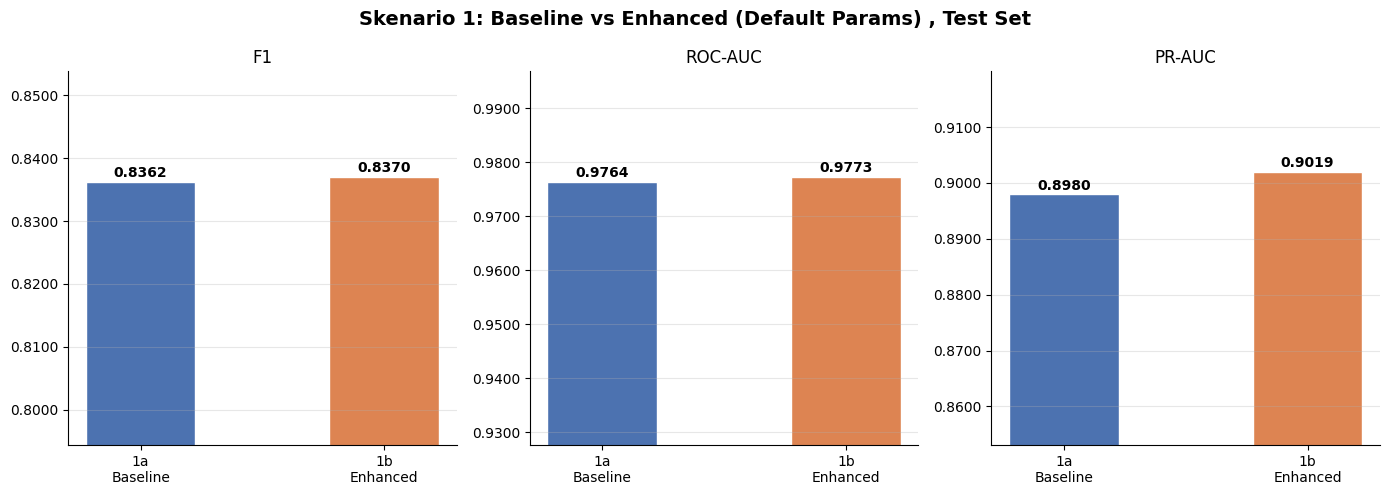

In [11]:
# ── Visualisasi Skenario 1
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Skenario 1: Baseline vs Enhanced (Default Params) , Test Set', fontsize=14, fontweight='bold')

metrics  = ['F1', 'ROC-AUC', 'PR-AUC']
val_1a   = [res_1a_test['f1'], res_1a_test['roc_auc'], res_1a_test['pr_auc']]
val_1b   = [res_1b_test['f1'], res_1b_test['roc_auc'], res_1b_test['pr_auc']]
colors   = ['#4C72B0', '#DD8452']

for i, (ax, metric, v1a, v1b) in enumerate(zip(axes, metrics, val_1a, val_1b)):
    bars = ax.bar(['1a\nBaseline', '1b\nEnhanced'], [v1a, v1b], color=colors, width=0.45, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(min(v1a, v1b) * 0.95, max(v1a, v1b) * 1.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    for bar, val in zip(bars, [v1a, v1b]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
# SKENARIO 2: Hyperparameter Tuning dengan Optuna
## Default Params (2a) vs Optuna Tuned (2b), Menggunakan Enhanced Dataset

### Skenario 2a Enhanced + Default Params (sama dengan 1b, di-reuse)

In [12]:
# Skenario 2a = Skenario 1b (model yang sama)
# Tidak perlu training ulang, langsung reuse lgb_1b
print('Skenario 2a = Skenario 1b (Enhanced + Default Params)')
print('   Model di-reuse dari lgb_1b, tidak perlu training ulang.')

res_2a_val  = res_1b_val
res_2a_test = res_1b_test

print(f'\n   Val  F1: {res_2a_val["f1"]:.4f}')
print(f'   Test F1: {res_2a_test["f1"]:.4f}')

Skenario 2a = Skenario 1b (Enhanced + Default Params)
   Model di-reuse dari lgb_1b, tidak perlu training ulang.

   Val  F1: 0.8330
   Test F1: 0.8370


### Skenario 2b Enhanced + Optuna Tuning (50 trials, optimize F1 di Val Set)

In [13]:
def objective(trial):
    """Optuna objective: optimize F1 di validation set."""
    params = {
        'n_estimators'     : 2000, # Diubah menjadi statis tinggi
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves',         20, 150), # Rentang dipersempit
        'max_depth'        : trial.suggest_int('max_depth',          3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples',  50, 500), # Rentang dinaikkan
        'subsample'        : trial.suggest_float('subsample',        0.5, 1.0),
        'subsample_freq'   : 1, # Tambahan wajib agar subsample aktif
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-8, 10.0, log=True),
        'scale_pos_weight' : get_scale_pos_weight(y_train),
        'random_state'     : RANDOM_SEED,
        'deterministic'    : True,
        'force_row_wise'   : True,
        'verbose'          : -1,
    }

    model = lgb.LGBMClassifier(**params)

    # eval_set + early stopping berbasis average_precision (lebih relevan untuk imbalance/F1
    # dibanding binary_logloss default)
    model.fit(
        X_train_enh, y_train,
        eval_set=[(X_val_enh, y_val)],
        eval_metric='average_precision',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Catat best_iteration agar bisa dicek konsistensinya nanti
    trial.set_user_attr('best_iteration', model.best_iteration_)

    y_pred_val = model.predict(X_val_enh)
    return f1_score(y_val, y_pred_val)

print('Menjalankan Optuna tuning (50 trials) ...')
t0 = time.time()
study = optuna.create_study(direction='maximize', study_name='lgbm_f1_tuning')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nTuning selesai dalam {time.time() - t0:.1f} detik')
print(f'   Best Trial #  : {study.best_trial.number}')
print(f'   Best Val F1   : {study.best_value:.4f}')
print(f'   Best Iteration: {study.best_trial.user_attrs["best_iteration"]}')
print(f'   Best Params  :')
for k, v in study.best_params.items():
    print(f'     {k:25s}: {v}')

Menjalankan Optuna tuning (50 trials) ...


  0%|          | 0/50 [00:00<?, ?it/s]


Tuning selesai dalam 391.2 detik
   Best Trial #  : 38
   Best Val F1   : 0.8469
   Best Iteration: 264
   Best Params  :
     learning_rate            : 0.06700034436311307
     num_leaves               : 55
     max_depth                : 12
     min_child_samples        : 419
     subsample                : 0.8785750072277402
     colsample_bytree         : 0.5704234869123941
     reg_alpha                : 1.0518610734325573e-08
     reg_lambda               : 1.4592035095006357


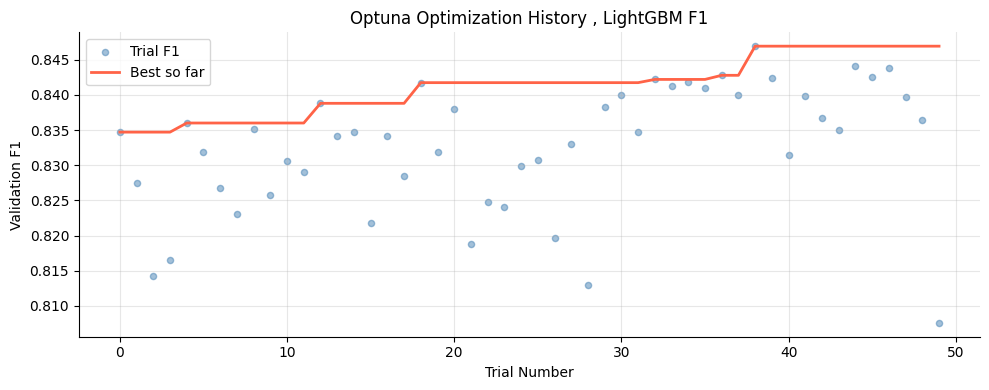

In [14]:
# ── Visualisasi Optuna: optimization history
trial_nums = [t.number for t in study.trials]
trial_vals = [t.value for t in study.trials]
best_so_far = pd.Series(trial_vals).cummax().values

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trial_nums, trial_vals, s=20, alpha=0.5, color='steelblue', label='Trial F1')
ax.plot(trial_nums, best_so_far, color='tomato', linewidth=2, label='Best so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Validation F1')
ax.set_title('Optuna Optimization History , LightGBM F1')
ax.legend()
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
# ── Training model terbaik dengan best params
print('Training model terbaik dari Optuna ...')
t0 = time.time()

best_params = study.best_params.copy()
best_params.update({
    'n_estimators'     : 2000,
    'subsample_freq'   : 1,
    'scale_pos_weight' : get_scale_pos_weight(y_train),
    'random_state'     : RANDOM_SEED,
    'deterministic'    : True,
    'force_row_wise'   : True,
    'verbose'          : -1,
})

lgb_2b = lgb.LGBMClassifier(**best_params)
lgb_2b.fit(
    X_train_enh, y_train,
    eval_set=[(X_val_enh, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print(f'   Selesai dalam {time.time() - t0:.1f} detik')
print(f'   Best iteration : {lgb_2b.best_iteration_}')
print(f'   (Bandingkan dengan best_iteration trial Optuna: {study.best_trial.user_attrs["best_iteration"]})')

Training model terbaik dari Optuna ...
   Selesai dalam 7.9 detik
   Best iteration : 264
   (Bandingkan dengan best_iteration trial Optuna: 264)


In [16]:
res_2b_val  = evaluate_model(lgb_2b, X_val_enh,  y_val,  label='2b, Enhanced + Tuned | Val Set')
res_2b_test = evaluate_model(lgb_2b, X_test_enh, y_test, label='2b, Enhanced + Tuned | Test Set')


  2b, Enhanced + Tuned | Val Set
  Threshold   : 0.500
  F1-Score    : 0.8469
  ROC-AUC     : 0.9779
  PR-AUC      : 0.9048

              precision    recall  f1-score   support

  No Default       0.98      0.95      0.97     30921
     Default       0.81      0.89      0.85      6586

    accuracy                           0.94     37507
   macro avg       0.89      0.92      0.91     37507
weighted avg       0.95      0.94      0.94     37507


  2b, Enhanced + Tuned | Test Set
  Threshold   : 0.500
  F1-Score    : 0.8490
  ROC-AUC     : 0.9789
  PR-AUC      : 0.9130

              precision    recall  f1-score   support

  No Default       0.98      0.95      0.97     30915
     Default       0.81      0.90      0.85      6585

    accuracy                           0.94     37500
   macro avg       0.89      0.93      0.91     37500
weighted avg       0.95      0.94      0.95     37500



### Ringkasan Skenario 2: Default Params vs Tuned

In [17]:
summary_2 = pd.DataFrame([
    {'Skenario': '2a, Default Params', 'Split': 'Val',  'F1': res_2a_val['f1'],  'ROC-AUC': res_2a_val['roc_auc'],  'PR-AUC': res_2a_val['pr_auc']},
    {'Skenario': '2b, Tuned (Optuna)', 'Split': 'Val',  'F1': res_2b_val['f1'],  'ROC-AUC': res_2b_val['roc_auc'],  'PR-AUC': res_2b_val['pr_auc']},
    {'Skenario': '2a, Default Params', 'Split': 'Test', 'F1': res_2a_test['f1'], 'ROC-AUC': res_2a_test['roc_auc'], 'PR-AUC': res_2a_test['pr_auc']},
    {'Skenario': '2b, Tuned (Optuna)', 'Split': 'Test', 'F1': res_2b_test['f1'], 'ROC-AUC': res_2b_test['roc_auc'], 'PR-AUC': res_2b_test['pr_auc']},
])

print('\nRINGKASAN SKENARIO 2:')
print(summary_2.to_string(index=False, float_format='{:.4f}'.format))


RINGKASAN SKENARIO 2:
          Skenario Split     F1  ROC-AUC  PR-AUC
2a, Default Params   Val 0.8330   0.9760  0.8937
2b, Tuned (Optuna)   Val 0.8469   0.9779  0.9048
2a, Default Params  Test 0.8370   0.9773  0.9019
2b, Tuned (Optuna)  Test 0.8490   0.9789  0.9130


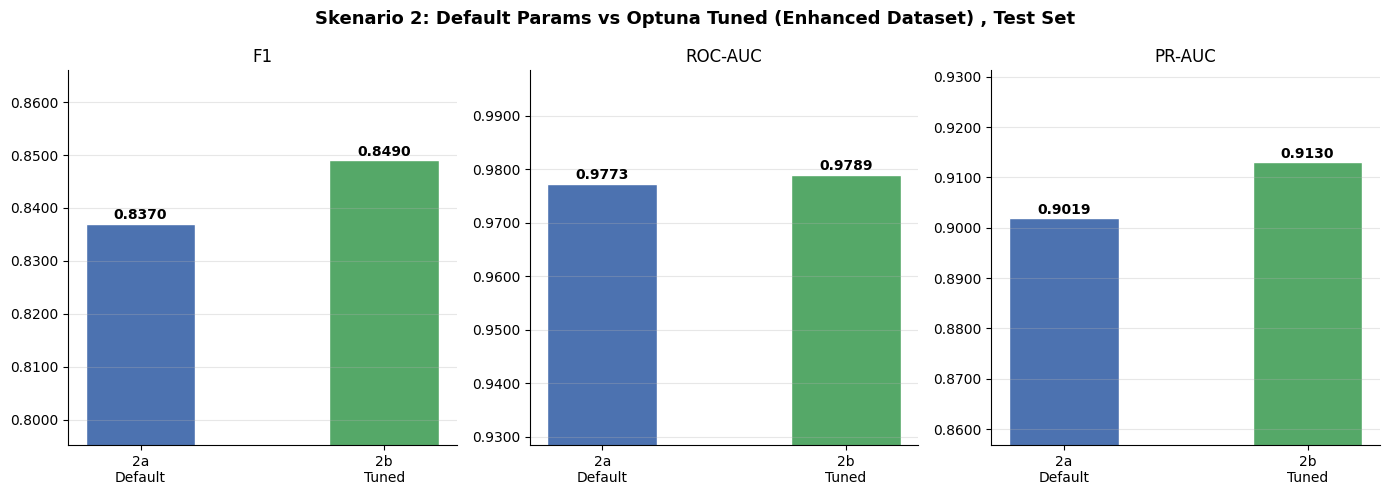

In [18]:
# ── Visualisasi Skenario 2
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Skenario 2: Default Params vs Optuna Tuned (Enhanced Dataset) , Test Set',
             fontsize=13, fontweight='bold')

metrics  = ['F1', 'ROC-AUC', 'PR-AUC']
val_2a   = [res_2a_test['f1'], res_2a_test['roc_auc'], res_2a_test['pr_auc']]
val_2b   = [res_2b_test['f1'], res_2b_test['roc_auc'], res_2b_test['pr_auc']]
colors   = ['#4C72B0', '#55A868']

for ax, metric, v2a, v2b in zip(axes, metrics, val_2a, val_2b):
    bars = ax.bar(['2a\nDefault', '2b\nTuned'], [v2a, v2b], color=colors, width=0.45, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(min(v2a, v2b) * 0.95, max(v2a, v2b) * 1.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    for bar, val in zip(bars, [v2a, v2b]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
# RINGKASAN AKHIR, Semua Skenario

In [19]:
summary_all = pd.DataFrame([
    {'Skenario': '1a, Baseline (no cluster)',     'Dataset': 'Baseline',  'Params': 'Default', 'F1 Val': res_1a_val['f1'],  'F1 Test': res_1a_test['f1'],  'ROC-AUC Test': res_1a_test['roc_auc'],  'PR-AUC Test': res_1a_test['pr_auc']},
    {'Skenario': '1b/2a, Enhanced (with cluster)', 'Dataset': 'Enhanced', 'Params': 'Default', 'F1 Val': res_1b_val['f1'],  'F1 Test': res_1b_test['f1'],  'ROC-AUC Test': res_1b_test['roc_auc'],  'PR-AUC Test': res_1b_test['pr_auc']},
    {'Skenario': '2b, Enhanced + Tuned',           'Dataset': 'Enhanced', 'Params': 'Optuna',  'F1 Val': res_2b_val['f1'],  'F1 Test': res_2b_test['f1'],  'ROC-AUC Test': res_2b_test['roc_auc'],  'PR-AUC Test': res_2b_test['pr_auc']},
])

print('\n' + '='*75)
print('  RINGKASAN AKHIR , LightGBM Skenario 1 & 2')
print('='*75)
print(summary_all.to_string(index=False, float_format='{:.4f}'.format))

# Highlight model terbaik
best_idx = summary_all['F1 Test'].idxmax()
print(f'\nModel terbaik (F1 Test): {summary_all.loc[best_idx, "Skenario"]}')
print(f'   F1 Test   : {summary_all.loc[best_idx, "F1 Test"]:.4f}')
print(f'   ROC-AUC   : {summary_all.loc[best_idx, "ROC-AUC Test"]:.4f}')
print(f'   PR-AUC    : {summary_all.loc[best_idx, "PR-AUC Test"]:.4f}')


  RINGKASAN AKHIR , LightGBM Skenario 1 & 2
                      Skenario  Dataset  Params  F1 Val  F1 Test  ROC-AUC Test  PR-AUC Test
     1a, Baseline (no cluster) Baseline Default  0.8318   0.8362        0.9764       0.8980
1b/2a, Enhanced (with cluster) Enhanced Default  0.8330   0.8370        0.9773       0.9019
          2b, Enhanced + Tuned Enhanced  Optuna  0.8469   0.8490        0.9789       0.9130

Model terbaik (F1 Test): 2b, Enhanced + Tuned
   F1 Test   : 0.8490
   ROC-AUC   : 0.9789
   PR-AUC    : 0.9130


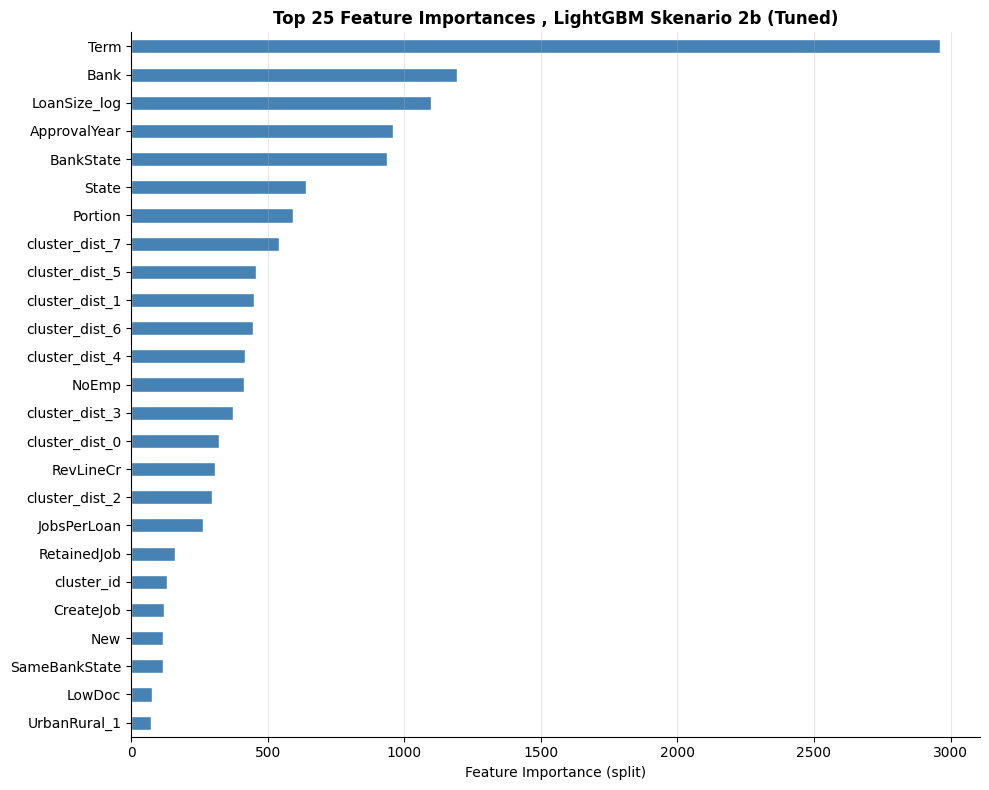

In [20]:
# ── Feature Importance, model terbaik (Skenario 2b)
feat_imp = pd.Series(
    lgb_2b.feature_importances_,
    index=X_train_enh.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 25 Feature Importances , LightGBM Skenario 2b (Tuned)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance (split)')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

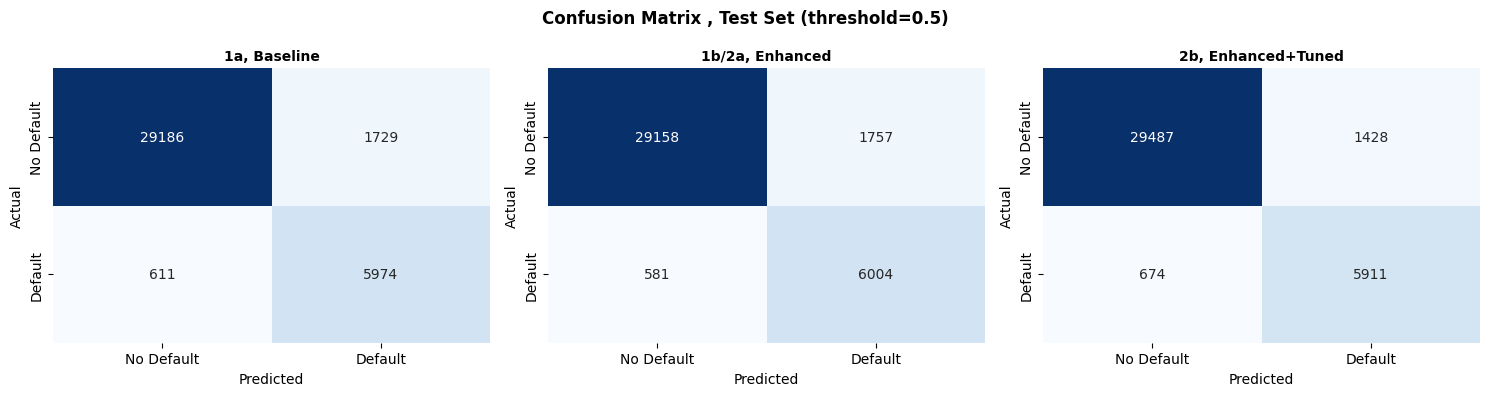

In [21]:
# ── Confusion Matrix, model terbaik di Test Set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix , Test Set (threshold=0.5)', fontsize=12, fontweight='bold')

configs = [
    ('1a, Baseline',       res_1a_test),
    ('1b/2a, Enhanced',    res_1b_test),
    ('2b, Enhanced+Tuned', res_2b_test),
]

for ax, (title, res) in zip(axes, configs):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'],
                cbar=False)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

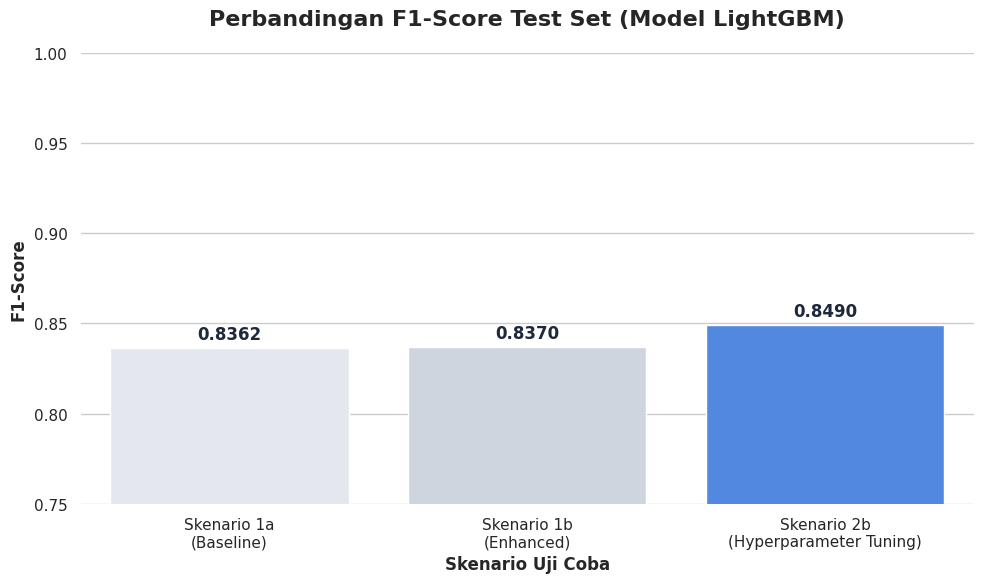

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. GANTI ANGKA INI dengan hasil F1-Score yang sudah muncul di notebook-mu
# ==============================================================================
skor_1a = 0.8362  # Ganti dengan angka persis dari output Skenario 1a
skor_1b = 0.8370  # Ganti dengan angka persis dari output Skenario 1b
skor_2b = 0.8490  # Ganti dengan angka persis dari output Skenario 2b

# ==============================================================================
# 2. Setup Data & Visualisasi (Bar Chart)
# ==============================================================================
scenarios = ['Skenario 1a\n(Baseline)', 'Skenario 1b\n(Enhanced)', 'Skenario 2b\n(Hyperparameter Tuning)']
f1_scores = [skor_1a, skor_1b, skor_2b]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Warna abu-abu untuk default, biru menyala untuk model terbaik (Tuned)
colors = ['#E2E8F0', '#CBD5E1', '#3B82F6'] 
ax = sns.barplot(x=scenarios, y=f1_scores, palette=colors)

# Menambahkan angka di atas masing-masing bar
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.4f'),
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='center',
                size=12, xytext=(0, 10),
                textcoords='offset points',
                fontweight='bold', color='#1E293B')

# Styling plot
plt.title('Perbandingan F1-Score Test Set (Model LightGBM)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.xlabel('Skenario Uji Coba', fontsize=12, fontweight='bold')

# Batas bawah grafik diubah agar perbedaan tinggi bar lebih mencolok
plt.ylim(0.75, 1.0) 
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()